# Programa de Ciencias de Datos.
Mi primer ML
Msc José Vásquez

1. Acceso a los datos

In [ ]:
# Librerias básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
datatrain= pd.read_csv('/content/sample_data/california_housing_train.csv', sep=",")
datatrain.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
15043,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
7576,-118.36,33.79,34.0,5166.0,704.0,2071.0,668.0,8.3609,500001.0
89,-115.57,32.83,31.0,1494.0,289.0,959.0,284.0,3.5282,67500.0
11413,-121.23,38.12,22.0,393.0,58.0,134.0,57.0,3.9500,178100.0
12178,-121.45,37.75,15.0,3846.0,677.0,2360.0,635.0,4.6173,164800.0


In [ ]:
datatest= pd.read_csv('/content/sample_data/california_housing_test.csv', sep=",")
datatrain.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
16640,-122.73,38.37,40.0,1389.0,309.0,841.0,288.0,3.1094,183300.0
494,-116.99,33.76,12.0,7626.0,1704.0,2823.0,1554.0,2.1722,69400.0
12847,-121.82,38.00,29.0,2070.0,452.0,985.0,420.0,2.8466,113400.0
15333,-122.29,38.31,25.0,4927.0,1005.0,2756.0,998.0,2.7325,162900.0
9778,-119.67,34.43,39.0,1467.0,381.0,1404.0,374.0,2.3681,241400.0


In [ ]:
print("Tamaño de datos de entrenamiento",datatrain.shape)
print("Tamaño de datos de prueba",datatest.shape)

Tamaño de datos de entrenamiento (17000, 9)
Tamaño de datos de prueba (3000, 9)


## 2. Conjunto de Entrenamiento, validación y prueba & Validación-Cruzada

- En cualquier problema ML, lo recomendable es trabajar con una tripe partición del universo de datos: Entrenamiento, Validación y Prueba

* Validación cruzada

## 3. Transformación durante el preprocesamiento

**Pipeline:** Tubería, facilita y automatiza el proceso de limpiado y preparación de los datos.

* Imputación
* Transformaciones de distribución
* Normalización o estandarización

In [ ]:
datatrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
sns.set(rc={'figure.figsize':(10,32)})

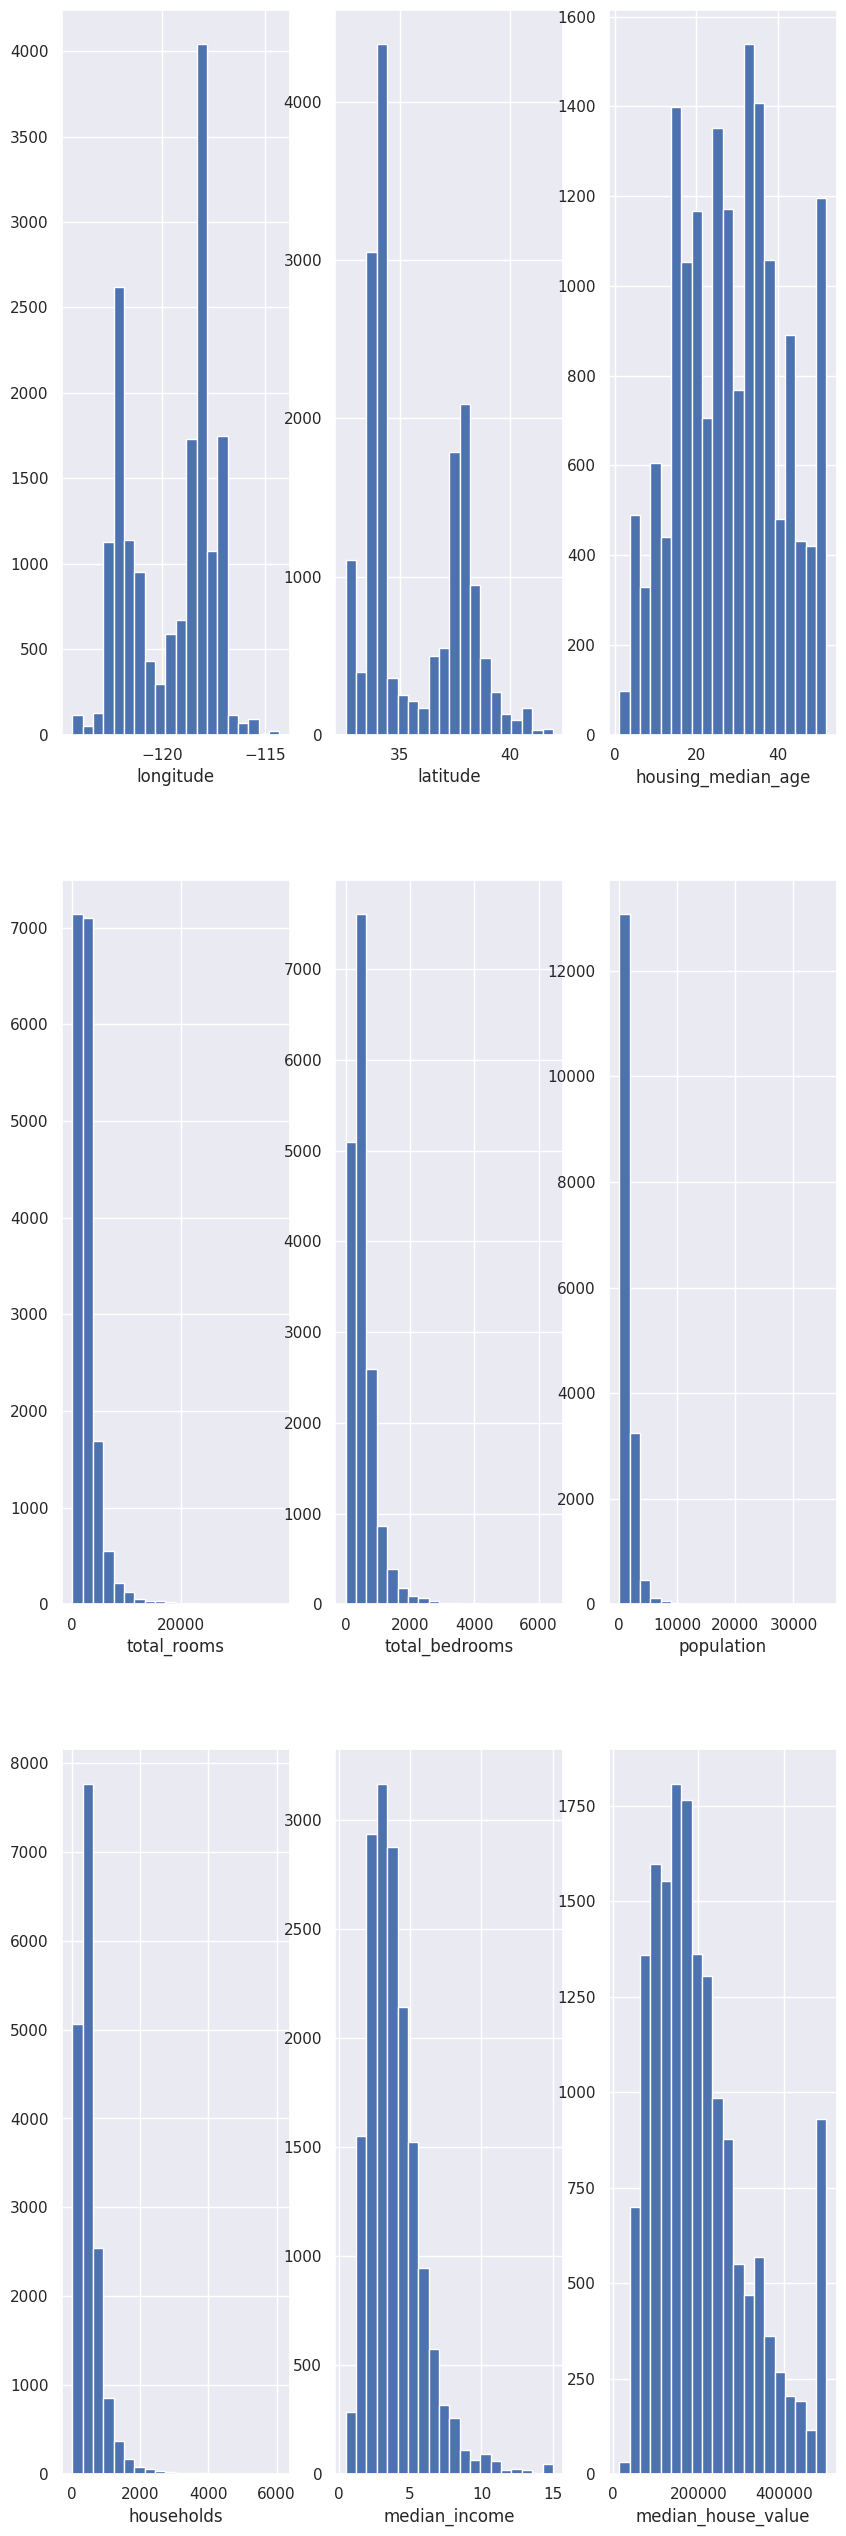

In [ ]:
fig, axes = plt.subplots(3, 3)    # Definimos una ventana de 3x3 nichos para incluir en cada uno de ellos un gráfico.

for k in range(0,9):

  plt.subplot(3,3,k+1)     # Los nichos para cada histograma se numeran iniciando en 1.

  plt.hist(datatrain[datatrain.columns[k]], bins=20)     # datatrain.columns nos devuelve una lista con los nombres de las columnas.

  plt.xlabel(datatrain.columns[k])

plt.show()

In [ ]:
datatrain.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


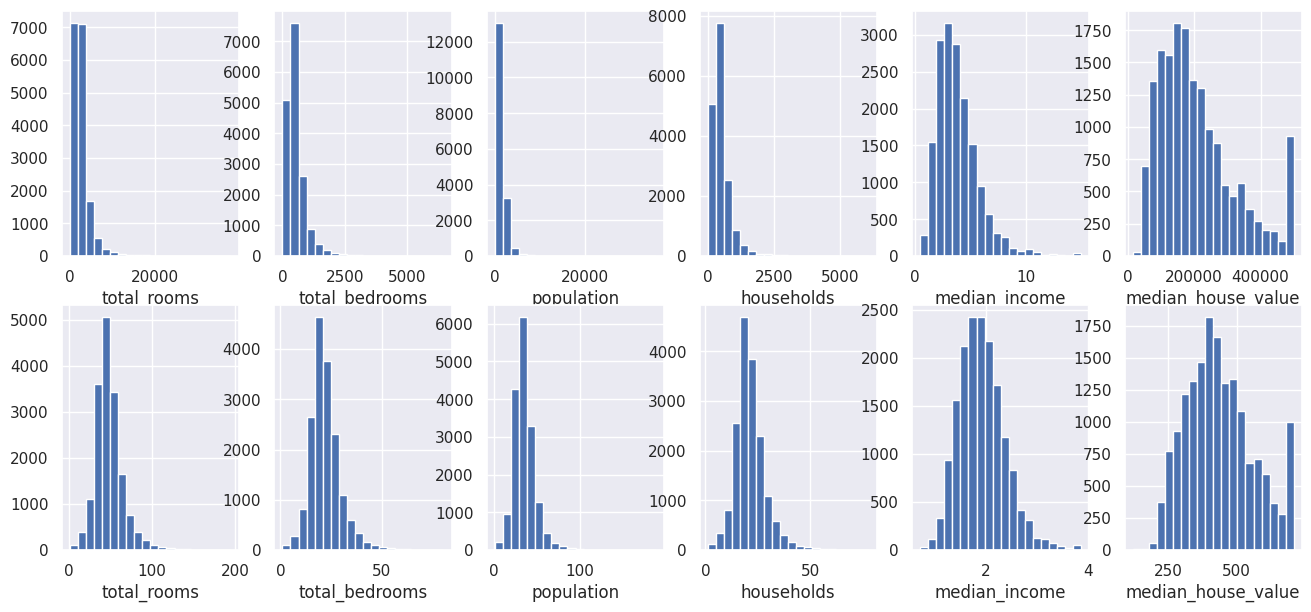

In [ ]:
sns.set(rc={'figure.figsize':(16,7)})



fig, axes = plt.subplots(2, 6)

for k in range(3,9):             # grafiquemos por el momento solo los factores con marcado sesgo positivo.

  plt.subplot(2,6,k-2)



  tmp = datatrain[datatrain.columns[k]]   # datos originales.

  plt.hist(tmp, bins=20)

  plt.xlabel(datatrain.columns[k])



  plt.subplot(2,6,k+4)

  tmp = np.sqrt(datatrain[datatrain.columns[k]])   # datos con alguna transformación para ajuste de la distribución.

  plt.hist(tmp, bins=20)

  plt.xlabel(datatrain.columns[k])



plt.show()

## 4. Métricas de desempeño

In [ ]:
# Definimos nuestra función del coeficiente de determinación ajustado a partir de las fórmulas dadas anteriormente, donde:

#    y_true: valores observados reales

#    y_hat : predicciones



# Suma de cuadrados de los errores:

def mi_SSE(y_true, y_hat):

  return sum( np.square(y_true - y_hat))



# Suma de cuadrados de la variabilidad total:

def mi_Syy(y_true, ymtrain):    # observa que se usa el valor promedio de las observaciones del conjunto de entrenamiento ymtrain.

  return sum( np.square(y_true - ymtrain))



# Coeficiente de determinación ajustado:

def mi_R2adj(sse, syy, n, k):

  tmp = ((n-1) / (n-k-1)) * (sse/syy)     # n:total de registros. k: total de variables independientes (predictores).

  return 1 - tmp    # coeficiente de determinación ajustado R2adj

In [ ]:
# Librerias
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold # Particiones de CV

In [ ]:
# Con los datos de entrenamiento
# Se generarán las particiobes dek CV( Cross validation)
Xtrain= datatrain.drop('median_house_value', axis='columns')
ytrain= datatrain['median_house_value']
#Lo mismo para los datos de prueba
Xtest= datatest.drop('median_house_value', axis='columns')
ytest= datatest['median_house_value']

Preprocesamiento:

In [ ]:
num_prepro_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler(feature_range=(1,2)))
    ]
)
num_prepro_nombre= list(Xtrain.columns)

#Transformar raiz cuadrada para las variables con sesgo
num_raiz_pipeline = Pipeline(
    steps=[
        ('sqrt', FunctionTransformer(np.sqrt))] #transformación
)
num_raiz_nombre= ['total_rooms', 'total_bedrooms', 'population', 'households',
                  'median_income']

# Aplicamos las transformaciones a las variable indicadas
ColumanasTransformar= ColumnTransformer(transformers=[('num_prepo',
num_prepro_pipeline, num_raiz_nombre)],
remainder= 'passthrough')

In [ ]:
# Seleccionbamos nuestro modelo de ML, en  nuestro caso RLM
modelo_LR= LinearRegression()
#Cálcul de metricas de desempeño
scoresR2Train= []
scoresR2Val= []
scoresmiR2Val= []
scoresmiR2adjVal= []
scoresRMSEVal= []
#iniciamos la cross validation usando KFOLD con k = 5
k=5
kf= KFold(n_splits=k, shuffle=True)



/tmp/ipykernel_854/4236241406.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, showmeans=True, vert=False)


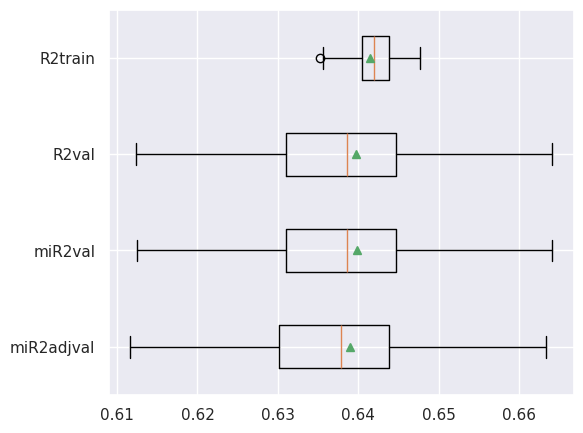

	  R2train 	R2val   	miR2val 	miR2adjval
fold[1]:  0.6476 	0.6124  	0.6125  	0.6116
fold[2]:  0.6404 	0.6448  	0.6448  	0.6439
fold[3]:  0.6439 	0.6306  	0.6306  	0.6298
fold[4]:  0.6405 	0.6446  	0.6446  	0.6438
fold[5]:  0.6353 	0.6633  	0.6633  	0.6625
fold[6]:  0.6444 	0.6281  	0.6285  	0.6276
fold[7]:  0.6435 	0.6321  	0.6323  	0.6315
fold[8]:  0.6356 	0.6641  	0.6641  	0.6634
fold[9]:  0.6418 	0.6391  	0.6392  	0.6384
fold[10]:  0.6420 	0.6380  	0.6381  	0.6372
mean(std) 0.641(0.004)  0.640(0.015)    0.640(0.015)    0.639(0.015)


In [ ]:
for train_index, val_index in kf.split(Xtrain):

  # En cada partición definimos ahora si el conjunto de entrenamiento
  # Y el de validación

  # Use .iloc to get subsets based on integer positions, and avoid re-assigning Xtrain and ytrain
  X_train_fold = Xtrain.iloc[train_index]
  X_val_fold = Xtrain.iloc[val_index]
  y_train_fold = ytrain.iloc[train_index]
  y_val_fold = ytrain.iloc[val_index]

  # Aplicamos la transformaciónes al conjunto de entrenamiento:
  XtrainFit = ColumanasTransformar.fit(X_train_fold)#Generamos la información
  #necesaria con el conjunto de entrenamiento
  X_trainTransf = XtrainFit.transform(X_train_fold) #Aplicamos la
  #transformación al conjunto de entrenamiento
  X_valTransf = XtrainFit.transform(X_val_fold) #Aplicamos las transformaciones
  # al conjunto de validación
  ymtrain_fold = y_train_fold.mean()# Promedio de las observaciones del conjunto
  # de entrenamiento, nos va a servir para calcular Syy

  #Generemos el modelo de regresión líneal con los datos de entrenamiento
  # de cada partición
  modelo_LR = modelo_LR.fit(X_trainTransf, y_train_fold)
  scoresR2Train.append(modelo_LR.score(X_trainTransf, y_train_fold))
  # linea anterior R2 del conjunto de entrenamiento
  yhat = modelo_LR.predict(X_valTransf) # Predicciones del conjunto de validación
  scoresR2Val.append(modelo_LR.score(X_valTransf, y_val_fold))# Guardamos los valores
  # para calcular el r2 del conjunto de validación

  # Calcularemos el valor r2 con nuestras formulas, con una pequeña filtración
  sse = mi_SSE(y_val_fold, yhat)
  syy = mi_Syy(y_val_fold, ymtrain_fold) # Esta función evita la filtracion de
  # informacion al usar el promedio de los datos de entrenamiento
  scoresmiR2Val.append(1-(sse/syy))

  # Calcular R ajustado
  tmp = mi_R2adj(sse,syy,X_valTransf.shape[0],X_valTransf.shape[1])

  scoresmiR2adjVal.append(tmp)

  #RMSE
  # Changed: Removed 'squared=False' and compute square root of MSE
  ss = np.sqrt(mean_squared_error(y_val_fold, yhat))


  scoresRMSEVal.append(ss)

  # Mostremos los diagramas de caja de los resultados obtenidos:

results = [scoresmiR2adjVal,scoresmiR2Val,scoresR2Val,scoresR2Train]

names = ['miR2adjval','miR2val','R2val','R2train']


sns.set(rc={'figure.figsize':(6,5)})

plt.boxplot(results, tick_labels=names, showmeans=True, vert=False) # Changed 'labels' to 'tick_labels'

plt.show()

# Despleguemos los resultados de los diferentes coeficientes de determinación obtenidos:


print("\t  %s \t%s   \t%s \t%s" % (names[3],names[2],names[1],names[0]))


for i,z in enumerate(zip(scoresR2Train, scoresR2Val, scoresmiR2Val, scoresmiR2adjVal)):

  print("fold[%d]:  %.4f \t%.4f  \t%.4f  \t%.4f" % (i+1,z[0],z[1],z[2],z[3]))


print("mean(std) %.3f(%.3f)  %.3f(%.3f)    %.3f(%.3f)    %.3f(%.3f)" % (np.mean(scoresR2Train), np.std(scoresR2Train),

                                                                        np.mean(scoresR2Val), np.std(scoresR2Val),

                                                                        np.mean(scoresmiR2Val), np.std(scoresmiR2Val),

                                                                        np.mean(scoresmiR2adjVal), np.std(scoresmiR2adjVal)))

In [ ]:
# Y ahora despleguemos los valores de RMSE de validación de cada partición:



print("\t  RMSEval")
for i,s in enumerate(scoresRMSEVal):

  print("fold[%d]:  %.2f" % (i+1,s))
 #print("\t %.2f (%.2f)" % (np.mean(scoresMSEVal), np.std(scoresMSEVal)))

print("mean(std) %.2f (%.2f)" % (np.mean(scoresRMSEVal), np.std(scoresRMSEVal)))

	  RMSEval
fold[1]:  71733.65
fold[2]:  68745.00
fold[3]:  70777.37
fold[4]:  68365.89
fold[5]:  68569.90
mean(std) 69638.36 (1359.89)


## 6. Modelo Final, conjunto test y conclusiones

In [ ]:
# Inicializamos de nuevo nuestro mejor modelo con sus parámetros predeterminados:

modelo_LRf = LinearRegression()

# Ajustamos las transformaciones con el conjunto de "entrenamiento aumentado", i.e., el train-set

# completo del archivo inicial, pero con los MISMOS PASOS que ya se decidieron en la etapa de entrenamiento previa:

XtrainTf = ColumanasTransformar.fit(Xtrain)

XtrainFTf = XtrainTf.transform(Xtrain)   # Aplicamos las mejores transformaciones  a los datos completos de train.

XtestFTf = XtrainTf.transform(Xtest)     # Aplicamos las transformaciones a Test con la información de Train para evitar la filtración.

                                         # Observa que esta es la primera vez que usamos los datos de prueba (Test) desde que iniciamos.

modelo_LRf = modelo_LRf.fit(XtrainFTf, ytrain)   # Entrenamos el mejor modelo con el conjunto de "entrenamiento aumentado".

yhatf = modelo_LRf.predict(XtestFTf)    # Generamos las predicciones con los datos de prueba (Test).

ymtrainf = np.mean(ytrain)     # Obtenemos el promedio de los datos de entrenamiento (recuerda que sklearn no nos regresa R2adj).

ssef = mi_SSE(ytest, yhatf)

syyf = mi_Syy(ytest, ymtrainf)

miR2adjf = mi_R2adj(ssef,syyf,XtestFTf.shape[0],XtestFTf.shape[1])   # Obtenemos R2adj con nuestra función que definimos previamente.

print("Métricas de desempeño del modelo final obtenido con el conjunto de prueba:")

print("Coeficiente de determinación ajustado: miR2adj = %.4f" % miR2adjf)

#print("Coeficiente de determinación R2 con filtración: %.4f" % modelo_LRf.score(XtestFTf, ytest))

RMSEtestf = np.sqrt(mean_squared_error(ytest, yhatf))

print("Raíz del error cuadrático medio: RMSE = %.2f" % RMSEtestf)

Métricas de desempeño del modelo final obtenido con el conjunto de prueba:
Coeficiente de determinación ajustado: miR2adj = 0.6186
Raíz del error cuadrático medio: RMSE = 69765.36
